In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

<br><br>

## 1. Load data

In [43]:
df = pd.read_csv("env_clean.csv")
df.head()

,census_tract,county,location,population,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight
0,6001400100,Alameda,Berkeley,3094,4.369906,7.135387,0.095739,934.715,0.029251,17.36,7.29,9.1,7.03
1,6001400200,Alameda,Oakland,2093,5.046525,7.348713,0.171673,1753.647,0.028516,20.69,7.04,7.0,4.13
2,6001400300,Alameda,Oakland,5727,4.971513,7.446539,0.155387,1617.707,0.028516,26.72,7.51,7.4,4.51
3,6001400400,Alameda,Oakland,4395,4.986183,7.451338,0.160767,1253.706,0.028516,37.93,8.89,6.5,3.06
4,6001400500,Alameda,Oakland,3822,4.496636,7.451338,0.133439,484.944,0.028516,49.55,9.87,7.2,5.50


In [44]:
health_vars = ["asthma", "cardiovascular_disease", "diabetes", "low_birth_weight"]
pollute_vars = ["PollutionScore", "pm25", "diesel_pm", "traffic_density", "ozone"]
la_df = df[df["county"] == "Los Angeles"][["county"] + ["location"] + pollute_vars + health_vars].copy()
la_df.head()

,county,location,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight
1343,Los Angeles,Tujunga,3.568500,9.009933,0.008410,247.199,0.057895,25.74,18.71,11.1,4.90
1344,Los Angeles,Tujunga,3.188737,8.693448,0.002255,234.436,0.058189,25.68,18.50,11.6,5.70
1345,Los Angeles,Tujunga,3.748258,9.064699,0.010217,387.100,0.057608,25.81,18.92,12.5,5.38
1346,Los Angeles,Tujunga,3.547352,9.009933,0.017072,327.868,0.057608,25.81,18.92,12.2,4.03
1347,Los Angeles,Tujunga,3.588890,9.064699,0.013518,327.595,0.057608,25.81,18.92,12.5,4.92


<br><br>
<br><br>

## 2. Access all variables and their data types

In [45]:
la_df["county"] = df["county"].astype("category")
la_df["location"] = df["location"].astype("category")
la_df.dtypes

county                    category
location                  category
PollutionScore             float64
pm25                       float64
diesel_pm                  float64
traffic_density            float64
ozone                      float64
asthma                     float64
cardiovascular_disease     float64
diabetes                   float64
low_birth_weight           float64
dtype: object

<br><br>
<br><br>

## 3. Analysis of diseases

<br>

##### **Statistics for disease variables**

**Disease distribution in California**

In [46]:
disease = ["asthma", "cardiovascular_disease", "diabetes", "low_birth_weight"]
df[disease].describe()

,asthma,cardiovascular_disease,diabetes,low_birth_weight
count,8859.000000,8859.000000,8859.000000,8859.000000
mean,38.360300,14.504499,11.662580,5.552789
std,18.530283,5.113487,2.801279,1.774564
min,0.660000,0.560000,1.900000,0.000000
25%,25.250000,10.460000,9.800000,4.380000
50%,35.540000,13.910000,11.500000,5.460000
75%,47.080000,17.980000,13.500000,6.650000
max,246.070000,37.210000,30.900000,17.390000


**Disease distribution in Los Angeles**

In [47]:
disease = ["asthma", "cardiovascular_disease", "diabetes", "low_birth_weight"]
la_df[disease].describe()

,asthma,cardiovascular_disease,diabetes,low_birth_weight
count,2434.000000,2434.000000,2434.000000,2434.000000
mean,41.085616,15.331997,12.543016,5.860924
std,20.074759,4.890704,2.938223,1.856354
min,9.390000,5.520000,4.400000,0.000000
25%,26.815000,11.472500,10.500000,4.600000
50%,39.140000,15.195000,12.700000,5.790000
75%,50.040000,18.500000,14.600000,7.040000
max,121.360000,30.510000,30.900000,15.000000


**Observation**

The LA county has much higher mean and minimum value of population having health issues obviously through comparisons. 

<br><br>

##### **Visualizing statistics for disease variables with Histograms**

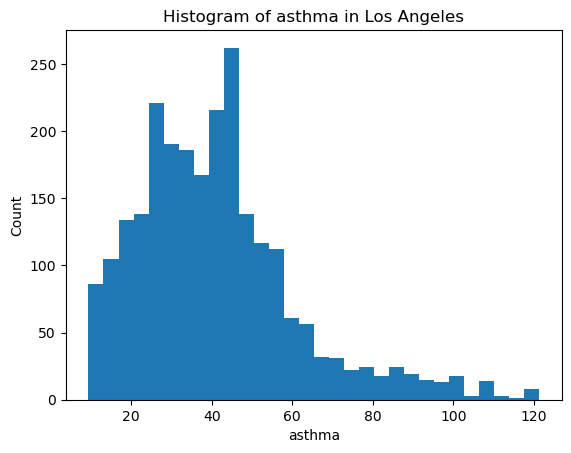

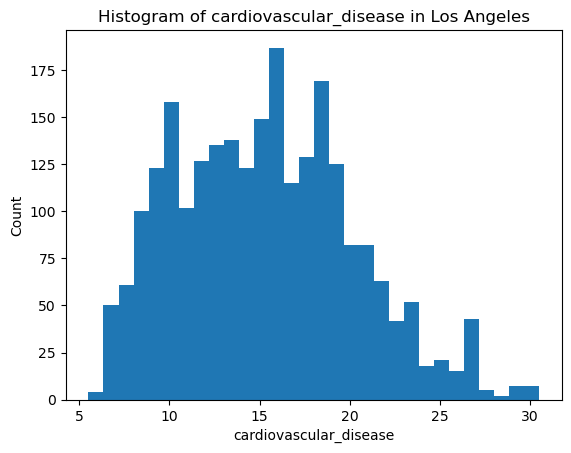

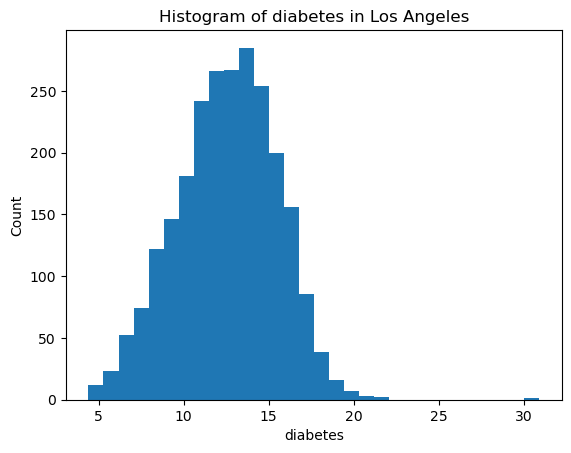

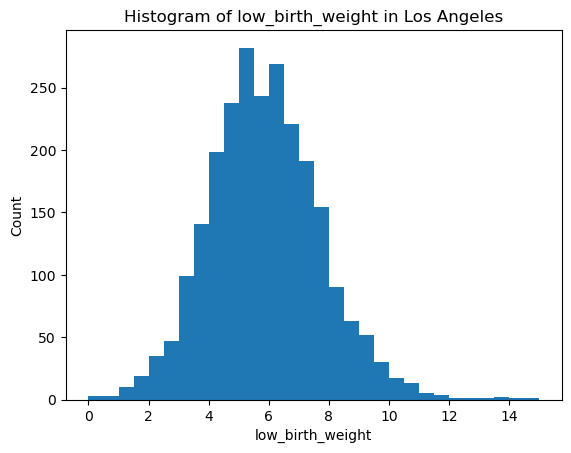

In [48]:
for item in disease:
    plt.hist(la_df[item], bins=30)
    plt.xlabel(item)
    plt.ylabel("Count")
    plt.title("Histogram of " + item + " in Los Angeles")
    plt.show()

<br><br>

##### **Visualizing statistics for disease variables with Boxplots**

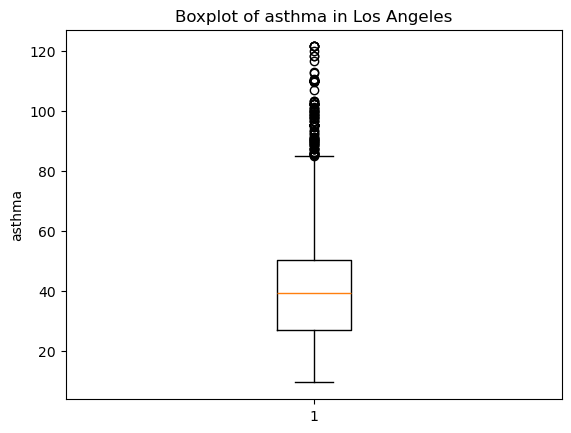

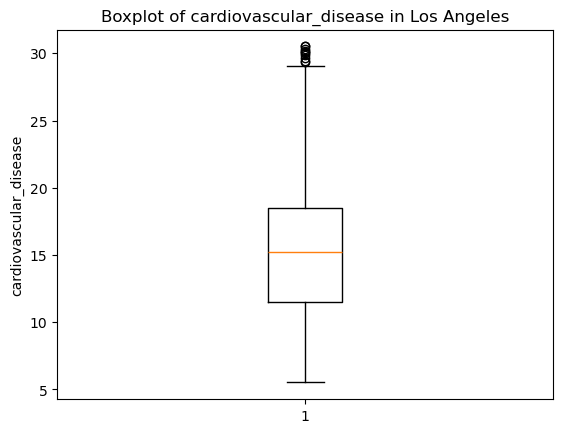

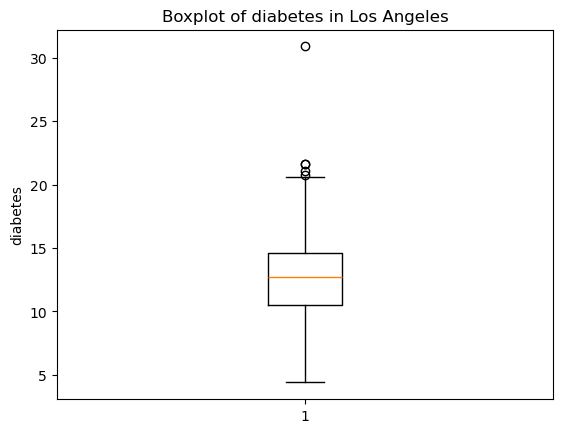

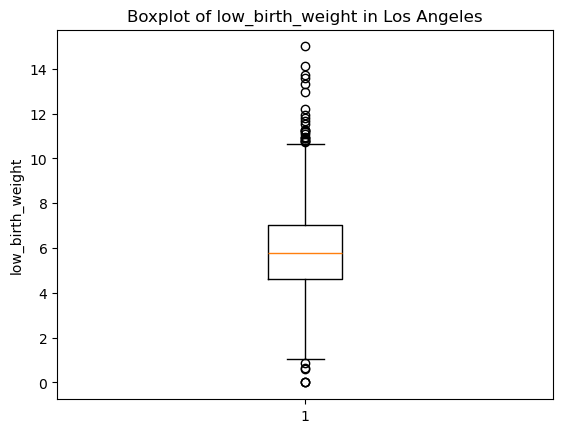

In [49]:
for item in disease:
    plt.boxplot(la_df[item])
    plt.ylabel(item)
    plt.title("Boxplot of " + item + " in Los Angeles")
    plt.show()

<br>

**Observations**

The histograms showed the distribution of asthma, cardiovascular disease, diabetes, and low birth weight in different communities. The boxplots identified the outliers and extreme statistics of each disease in different communities. The graphs do show a number of outliers with higher statistics of the diseases. 

<br><br>
<br><br>

## 4. Correlation Table and Heatmaps

<br>

##### **Creating correlation table in between each health outcome**

In [50]:
disease_corr = la_df[disease].corr()
disease_corr

,asthma,cardiovascular_disease,diabetes,low_birth_weight
asthma,1.000000,0.732589,0.564723,0.417795
cardiovascular_disease,0.732589,1.000000,0.564364,0.332874
diabetes,0.564723,0.564364,1.000000,0.321225
low_birth_weight,0.417795,0.332874,0.321225,1.000000


<br><br>

##### **Creating the heatmap from the corrlatoin in between each health outcome**

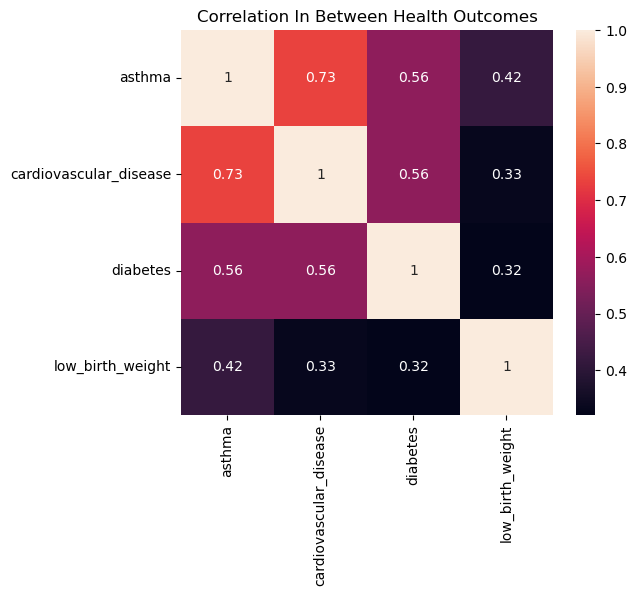

In [51]:
plt.figure(figsize=(6, 5))
sns.heatmap(disease_corr, annot=True)
plt.title("Correlation In Between Health Outcomes")
plt.show()

<br>

**Observations**: 

According to the interior correlation table and heatmap between the health outcomes, we notice some strong correlationships in between the disease variables. For example, the correlationship between cardiovascular disease and asthma, the correlationship between cardiovascular disease and diabetes, and the correlationship between diabetes and asthma, all reach a value over or equal to 0.5, indicating that a number of communities are experiencing multiple health issues at the same time. Whenever one health problem exists in the community, it is likely that other health problems listed above also exist along with the other. In the scatterplot section, we will emphasize on these strongly correlated variables. 

<br><br>

##### **Creating the correlation table between the health outcomes and the pollution variables**

In [52]:
env = ["PollutionScore", "pm25", "diesel_pm", "traffic_density", "ozone"]
all_vars = env + disease
env_disease_corr = la_df[all_vars].corr()
env_disease_corr.loc[env, disease]

,asthma,cardiovascular_disease,diabetes,low_birth_weight
PollutionScore,0.123054,0.218734,0.299869,0.114202
pm25,0.031867,0.202885,0.301141,0.089325
diesel_pm,0.018443,0.016795,0.052032,0.033360
traffic_density,-0.026364,0.030458,0.025097,0.014009
ozone,-0.050791,-0.001651,-0.023411,-0.033425


<br><br>

##### **Creating the heatmap from the correlation table between the health outcomes and pollution variables**

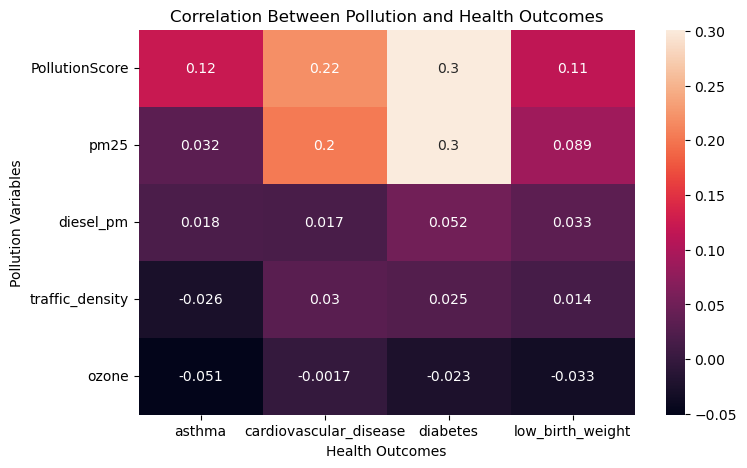

In [53]:
plt.figure(figsize=(8, 5))
sns.heatmap(env_disease_corr.loc[env, disease], annot=True)
plt.title("Correlation Between Pollution and Health Outcomes")
plt.xlabel("Health Outcomes")
plt.ylabel("Pollution Variables")
plt.show()

<br>

**Observations**:

The correlaiton table and healmap between pollution variables and health outcomes showed that there is a relatively strong correlationship between pollution score and diabetes as well as between PM2.5 and diabetes. The other correlationships between pollution variables and health outcomes are not strong, or even have little relationships, which means that the pollution variables we focused on may not be the main factors causing the health problems. However, it is still not certain if the variables are completely independent or if there are outliers in the data that affect the values produced. In the scatterplot section, we will graph both the strong correlation and the weak corerlation to visualize the data better. 

<br><br>
<br><br>

## 5. Scatterplots

<br>

##### **Asthma VS. Cardiovascular Disease**

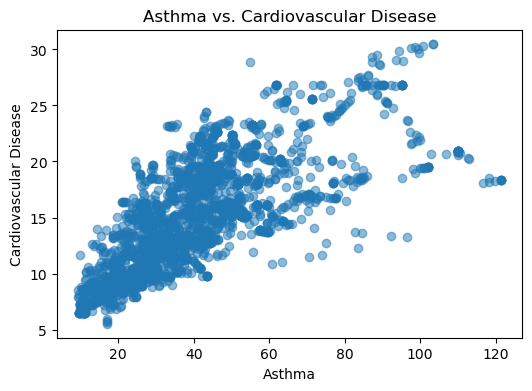

In [54]:
plt.figure(figsize=(6, 4))
plt.scatter(la_df["asthma"], la_df["cardiovascular_disease"], alpha=0.5)
plt.xlabel("Asthma")
plt.ylabel("Cardiovascular Disease")
plt.title("Asthma vs. Cardiovascular Disease")
plt.show()

**Observation**: 

The scatterplot between cardiovascular disease and asthma follows an obvious pattern that the two health outcomes are correlated. The two health outcome variables have a positive relationship. 

<br><br>

##### **Diabetes VS. Cardiovascular Disease**

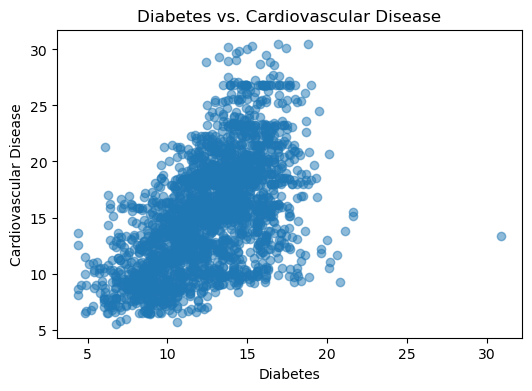

In [55]:
plt.figure(figsize=(6, 4))
plt.scatter(la_df["diabetes"], la_df["cardiovascular_disease"], alpha=0.5)
plt.xlabel("Diabetes")
plt.ylabel("Cardiovascular Disease")
plt.title("Diabetes vs. Cardiovascular Disease")
plt.show()

**Observations**

There is a strong positive correlation between diabetes and cardiovascular diseases through the graph. 

<br><br>

##### **Diabetes VS. Cardiovascular Disease**

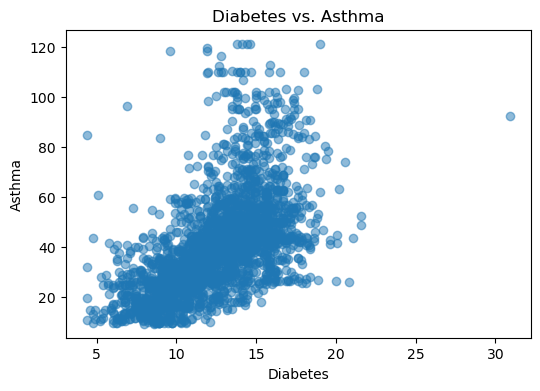

In [56]:
plt.figure(figsize=(6, 4))
plt.scatter(la_df["diabetes"], la_df["asthma"], alpha=0.5)
plt.xlabel("Diabetes")
plt.ylabel("Asthma")
plt.title("Diabetes vs. Asthma")
plt.show()

**Observation**

There are a number of outliers shown in the graph that may increase the value of correlation as we stated before.

<br><br>

##### **PM2.5 VS. Diabetes**


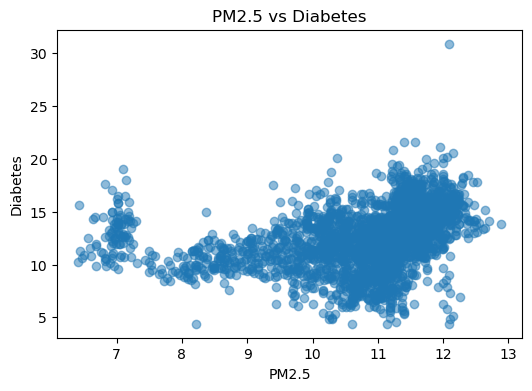

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(la_df["pm25"], la_df["diabetes"], alpha=0.5)
plt.xlabel("PM2.5")
plt.ylabel("Diabetes")
plt.title("PM2.5 vs Diabetes")
plt.show()

**Observations**:

The scatterplot between PM2.5 and diabetes shows a slight postive relationship pattern. It means that the existence of PM2.5 in the atmosphere is possible to cause the risk of having diabetes in the community. 

<br><br>

##### **Pollution Score VS. Diabetes**

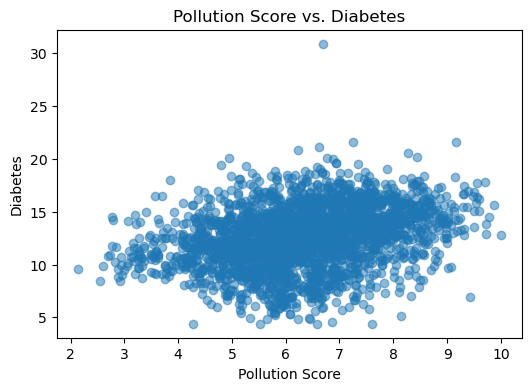

In [58]:
plt.figure(figsize=(6, 4))
plt.scatter(la_df["PollutionScore"], la_df["diabetes"], alpha=0.5)
plt.xlabel("Pollution Score")
plt.ylabel("Diabetes")
plt.title("Pollution Score vs. Diabetes")
plt.show()

**Observations**:

There is relatively clear pattern of a positive relationship shown in the graph. Pollution Score and diabetes have a positive relationship, even though it is not a strong one. 

<br><br>
<br><br>

## 6. Normalization and VIF

<br>

In [59]:
scaler = StandardScaler()
df_scaled = la_df.copy()
df_scaled[env] = scaler.fit_transform(la_df[env])

X = la_df[env].dropna()
vif_table = pd.DataFrame()
vif_table["Variable"] = X.columns
vif_table["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_table

,Variable,VIF
0,PollutionScore,50.878421
1,pm25,73.776888
2,diesel_pm,1.209426
3,traffic_density,2.925698
4,ozone,24.539801


<br><br>
<br><br>

## 7. Regression

<br>

##### **Regression on Asthma**

In [88]:
target_outcome = "asthma"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 asthma   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     15.79
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.50e-15
Time:                        18:41:37   Log-Likelihood:                -10715.
No. Observations:                2434   AIC:                         2.144e+04
Df Residuals:                    2428   BIC:                         2.148e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          41.0856      0.401    102.494      0.000      40.300      41.872
PollutionScore      4.9486      0.593      8.344      0.000       3.786       6.112
pm25               -3.1440      0.639     -4.923      0.000      -4.396      -1.892
diesel_pm          -0.0127      0.411     -0.031      0.975      -0.820       0.794
traffic_density    -2.1122      0.448     -4.719      0.000      -2.990      -1.234
ozone              -1.3345      0.503     -2.655      0.008      -2.320      -0.349
==============================================================================
Omnibus:                      405.617   Durbin-Watson:                   0.186
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              700.313
Skew:                           1.071   Prob(JB):                    8.49e-153
Kurtosis:                       4.523   Cond. No.                         3.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The R-squared of regression on asthma is 0.031, so the data of pollution variables only explains 3.1% of the results of asthma. Given that the p values for the pollution variables are all smaller than 0.05 except diesel pm, the other 4 variables are significant in the regression. The coefficients of the pollution variables indicate that holding other variable values constant, pollution score is positively associated with asthma, while PM2.5, diesel pm, ozone, and traffic density are negatively associated with asthma.

<br><br>

##### **Regression on Cardiovascular Disease**

In [61]:
target_outcome = "cardiovascular_disease"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     cardiovascular_disease   R-squared:                       0.075
Model:                                OLS   Adj. R-squared:                  0.074
Method:                     Least Squares   F-statistic:                     39.64
Date:                    Sun, 07 Jun 2026   Prob (F-statistic):           2.84e-39
Time:                            18:21:03   Log-Likelihood:                -7221.3
No. Observations:                    2434   AIC:                         1.445e+04
Df Residuals:                        2428   BIC:                         1.449e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          15.3320      0.095    160.687      0.000      15.145      15.519
PollutionScore      0.8016      0.141      5.679      0.000       0.525       1.078
pm25                1.0117      0.152      6.655      0.000       0.714       1.310
diesel_pm          -0.1199      0.098     -1.224      0.221      -0.312       0.072
traffic_density    -0.2681      0.107     -2.517      0.012      -0.477      -0.059
ozone               0.8392      0.120      7.014      0.000       0.605       1.074
==============================================================================
Omnibus:                       70.391   Durbin-Watson:                   0.173
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               73.909
Skew:                           0.411   Prob(JB):                     8.93e-17
Kurtosis:                       2.770   Cond. No.                         3.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The data of pollution variables explains 7.5% of the results of cardiovascular disease. The variables are all statistically significant except diesel pm. Keeping other variables constant, increase in pollution score, PM2.5, and ozone will increase the existence of cardiovascular disease, while increase in diesel_pm and traffic density will decrease the existence of cardiovascular disease instead. 

<br><br>

##### **Regression on Diabetes**

In [62]:
target_outcome = "diabetes"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               diabetes   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     84.09
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.14e-81
Time:                        18:21:03   Log-Likelihood:                -5882.2
No. Observations:                2434   AIC:                         1.178e+04
Df Residuals:                    2428   BIC:                         1.181e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.5430      0.055    227.883      0.000      12.435      12.651
PollutionScore      0.5907      0.081      7.253      0.000       0.431       0.750
pm25                0.9266      0.088     10.568      0.000       0.755       1.099
diesel_pm          -0.0036      0.056     -0.064      0.949      -0.114       0.107
traffic_density    -0.2687      0.061     -4.372      0.000      -0.389      -0.148
ozone               0.6674      0.069      9.669      0.000       0.532       0.803
==============================================================================
Omnibus:                       29.820   Durbin-Watson:                   0.680
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.640
Skew:                          -0.072   Prob(JB):                     2.74e-11
Kurtosis:                       3.677   Cond. No.                         3.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**: 

The data of pollution variables explains 14.8% of the results of diabetes. The p value for diesel pm is too large, so except diesel pm, the other variables are significant. Keeping other variables constant, increase in pollution score, PM2.5, diesel pm, and ozone will increase the existence of diabetes, while increase in diesel pm and traffic density will decrease the existence of diabetes instead. 

<br><br>

##### **Regression on Low Birth Weight**

In [63]:
target_outcome = "low_birth_weight"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       low_birth_weight   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     7.293
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           8.60e-07
Time:                        18:21:03   Log-Likelihood:                -4940.8
No. Observations:                2434   AIC:                             9894.
Df Residuals:                    2428   BIC:                             9928.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           5.8609      0.037    156.767      0.000       5.788       5.934
PollutionScore      0.2076      0.055      3.754      0.000       0.099       0.316
pm25                0.0578      0.060      0.971      0.332      -0.059       0.175
diesel_pm           0.0245      0.038      0.639      0.523      -0.051       0.100
traffic_density    -0.0669      0.042     -1.603      0.109      -0.149       0.015
ozone               0.0388      0.047      0.828      0.408      -0.053       0.131
==============================================================================
Omnibus:                       88.106   Durbin-Watson:                   1.577
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              114.383
Skew:                           0.389   Prob(JB):                     1.45e-25
Kurtosis:                       3.724   Cond. No.                         3.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The data of pollution variables explains only 1.5% of the results of low birth weight. Only pollution score is significant, and it increase the existance of low birth weight. 

<br><br>
<br><br>

## 8. Community EDA

<br>

##### **Top 10 locations with highest pollution burden**

In [82]:
df_scaled["pollution_mean"] = df_scaled[env].mean(axis=1)
df_scaled["healthproblem_mean"] = df_scaled[disease].mean(axis=1)
df_sorted = df_scaled.sort_values("pollution_mean", ascending=False)
df_sorted.head(10)

,county,location,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight,pollution_mean,healthproblem_mean
1582,Los Angeles,Van Nuys,0.241371,-0.067082,34.143011,1.958966,1.228182,40.94,19.58,15.8,6.57,7.500889,20.7225
1479,Los Angeles,North Hills,0.004058,-0.253595,21.158048,2.102224,1.274473,44.31,17.41,15.2,7.45,4.857042,21.0925
2842,Los Angeles,South Pasadena,-0.231634,0.144812,9.929089,-0.611750,0.445016,22.50,9.59,10.9,2.71,1.935107,11.4250
2947,Los Angeles,Whittier,0.011630,0.298643,9.050598,-0.494734,-0.310445,31.90,13.52,10.7,5.82,1.711138,15.4850
3005,Los Angeles,Los Angeles,2.180682,1.393400,3.344773,1.838238,-0.256520,56.24,21.61,14.2,9.38,1.700115,25.3575
2395,Los Angeles,Harbor City,1.032269,0.014725,8.732314,-0.372403,-1.354182,46.35,16.11,13.5,6.91,1.610545,20.7175
2388,Los Angeles,Harbor City,0.475264,0.014725,8.273758,-0.200415,-1.354182,43.51,15.36,16.0,3.26,1.441830,19.5325
1939,Los Angeles,Los Angeles,1.600185,1.098806,4.532870,0.160417,-0.256520,63.39,11.00,20.2,4.76,1.427152,24.8375
2679,Los Angeles,Whittier,2.113497,0.628996,0.360748,3.655907,0.265147,38.39,18.17,15.1,5.44,1.404859,19.2750
2988,Los Angeles,Los Angeles,2.432663,1.233652,1.206177,2.255697,-0.256520,56.25,20.80,15.8,6.90,1.374334,24.9375


<br><br>

##### **Bar chart of top locations with highest pollution burden**

/var/folders/7v/rcrf3r9x0_v3n_yky8k3hgkc0000gn/T/ipykernel_1079/3803500505.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_env = (df_sorted.groupby("location")["pollution_mean"].mean().sort_values(ascending=False))


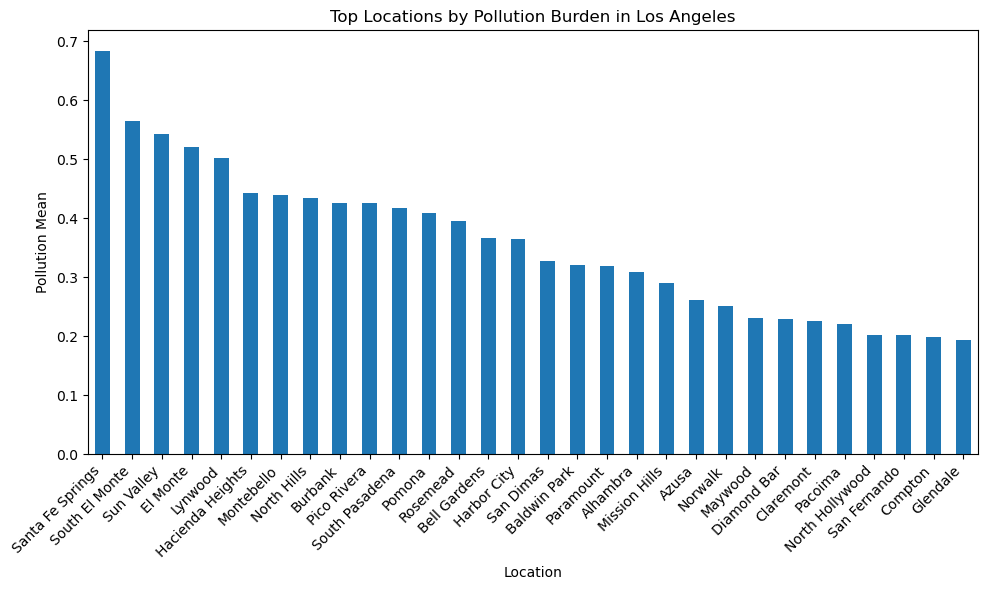

In [83]:
county_env = (df_sorted.groupby("location")["pollution_mean"].mean().sort_values(ascending=False))
top = county_env.head(30)
top.plot(x="location", y="pollution_mean", kind="bar", figsize=(10, 6))
plt.title("Top Locations by Pollution Burden in Los Angeles")
plt.xlabel("Location")
plt.ylabel("Pollution Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<br><br>

##### **Bar chart of top counties with highest health burden**

/var/folders/7v/rcrf3r9x0_v3n_yky8k3hgkc0000gn/T/ipykernel_1079/907360398.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_health = (df_sorted.groupby("location")["healthproblem_mean"].mean().sort_values(ascending=False))


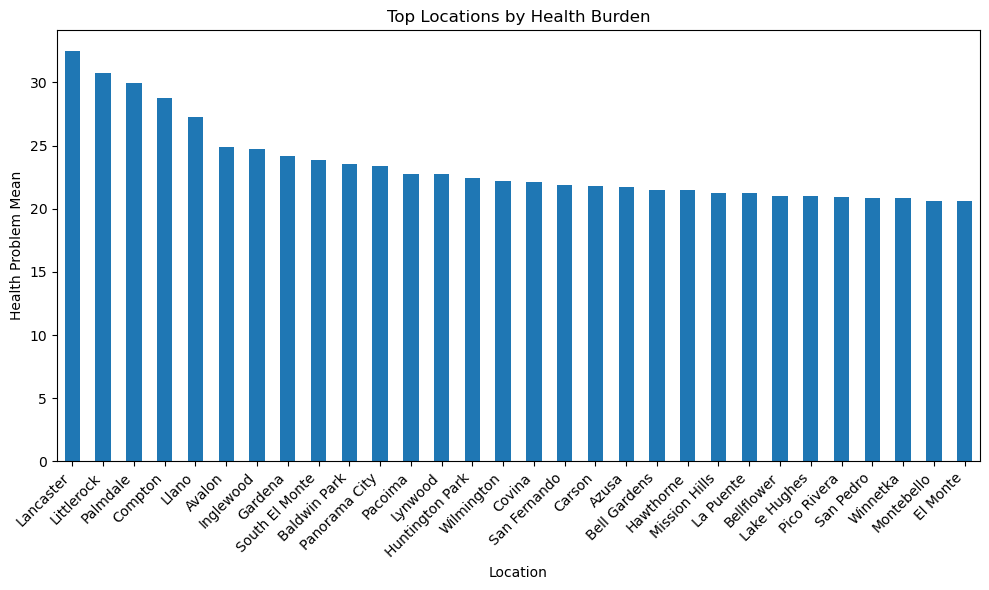

In [87]:
county_health = (df_sorted.groupby("location")["healthproblem_mean"].mean().sort_values(ascending=False))
top = county_health.head(30)
top.plot(x="location", y="healthproblem_mean", kind="bar", figsize=(10, 6))
plt.title("Top Locations by Health Burden")
plt.xlabel("Location")
plt.ylabel("Health Problem Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<br><br>

## 8. Port Activity

<br>

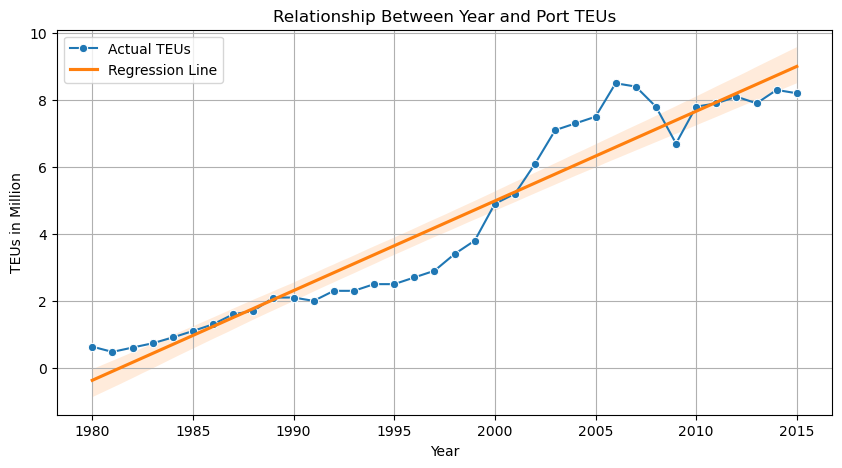

In [ ]:
port_clean = pd.read_csv("port_clean.csv")
plt.figure(figsize=(10, 5))
sns.lineplot(data=port_clean, x="Year", y="TEUs in Million", marker="o", label="Actual TEUs")
sns.regplot(data=port_clean, x="Year", y="TEUs in Million", scatter=False, label="Regression Line")
plt.xlabel("Year")
plt.ylabel("TEUs in Million")
plt.title("Relationship Between Year and Port TEUs")
plt.legend()
plt.grid(True)
plt.show()